In [1]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

2025-01-28 13:03:16.484695: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-28 13:03:16.544331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-28 13:03:17.528894: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [3]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot

In [6]:
from medmnist import DermaMNIST
data_train = DermaMNIST(split="train", download=True,size=64)

100%|██████████| 100M/100M [00:11<00:00, 9.01MB/s] 


In [22]:
DermaMNIST

medmnist.dataset.DermaMNIST

In [12]:
tr_images = data_train.imgs
tr_images.shape

(7007, 64, 64, 3)

In [21]:
tr_images

array([[[[153, 109, 111],
         [155, 114, 119],
         [155, 112, 120],
         ...,
         [183, 157, 167],
         [181, 155, 166],
         [180, 153, 163]],

        [[156, 113, 117],
         [156, 113, 119],
         [158, 117, 122],
         ...,
         [183, 157, 168],
         [182, 155, 166],
         [179, 152, 159]],

        [[157, 111, 118],
         [157, 110, 116],
         [159, 118, 120],
         ...,
         [184, 157, 167],
         [183, 156, 163],
         [181, 154, 159]],

        ...,

        [[176, 142, 152],
         [177, 146, 155],
         [178, 146, 156],
         ...,
         [183, 147, 147],
         [184, 149, 150],
         [183, 149, 147]],

        [[173, 140, 145],
         [175, 143, 149],
         [174, 141, 146],
         ...,
         [184, 150, 152],
         [185, 152, 156],
         [185, 151, 154]],

        [[168, 134, 137],
         [172, 138, 142],
         [171, 137, 138],
         ...,
         [184, 148, 152],
        

In [20]:
tr_images_r

array([[[153, 155, 155, ..., 183, 181, 180],
        [156, 156, 158, ..., 183, 182, 179],
        [157, 157, 159, ..., 184, 183, 181],
        ...,
        [176, 177, 178, ..., 183, 184, 183],
        [173, 175, 174, ..., 184, 185, 185],
        [168, 172, 171, ..., 184, 186, 185]],

       [[222, 222, 222, ..., 219, 221, 220],
        [224, 222, 223, ..., 215, 216, 218],
        [220, 220, 221, ..., 216, 218, 218],
        ...,
        [212, 213, 216, ..., 211, 212, 211],
        [211, 212, 213, ..., 211, 211, 211],
        [212, 212, 211, ..., 210, 210, 212]],

       [[228, 232, 232, ..., 240, 238, 237],
        [226, 229, 229, ..., 238, 237, 236],
        [223, 225, 226, ..., 235, 233, 232],
        ...,
        [194, 198, 198, ..., 214, 213, 213],
        [195, 195, 199, ..., 214, 212, 211],
        [197, 194, 195, ..., 213, 211, 211]],

       ...,

       [[ 22,  25,  28, ...,  16,  13,  11],
        [ 25,  27,  32, ...,  29,  15,  12],
        [ 26,  31,  50, ...,  55,  29,  14

In [18]:
tr_images_r.shape

(7007, 64, 64)

In [16]:
tr_labels = data_train.labels
tr_labels.shape

(7007, 1)

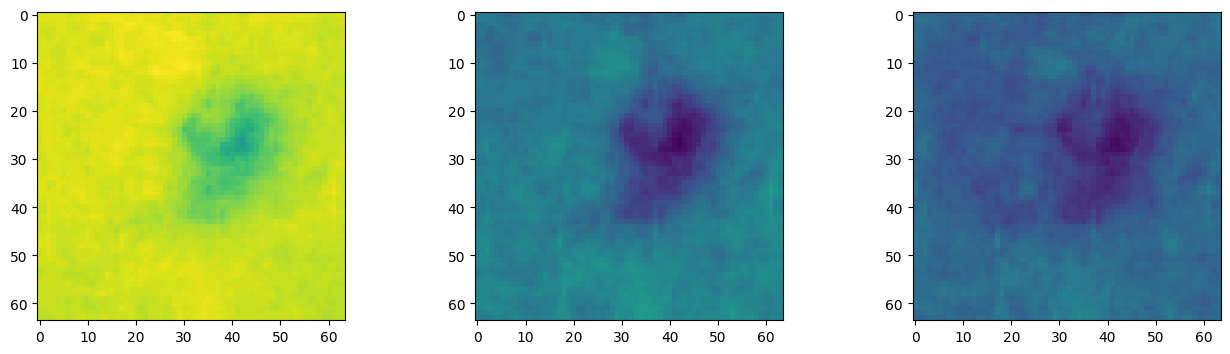

In [15]:
from matplotlib import pyplot as plt



post = tr_images[1,:,:,:]

_min, _max = np.amin(post), np.amax(post)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(3):
    axes[c].imshow(post[:,:,c],vmin = _min, vmax = _max)

In [ ]:
def preset():
    # from tensorflow import keras
    # skin_cancer_dataset_dataset = keras.datasets.skin_cancer_dataset
    from medmnist import DermaMNIST
    data_train = DermaMNIST(split="train", download=True,size=64)
    data_test = DermaMNIST(split="test", download=True,size=64)
    tr_layer = mq.ConvolutionLayer4x4("results_skin_train")
    te_layer = mq.ConvolutionLayer4x4("results_skin_test")
    
    tr_images = data_train.imgs
    tr_labels = data_train.labels
    te_images = data_test.imgs
    te_labels = data_test.labels
    # (tr_images, tr_labels), (te_images, te_labels) = skin_cancer_dataset_dataset.load_data()
    
    # tr_images = tr_images [:50:]
    # tr_labels = tr_labels[:50]
    # te_images = te_images[:10:]
    # te_labels = te_labels[:10]
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes